# Exercice 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# 1-Chargement des donnees et initialisation:

In [ ]:

(X_train, y_train) , (X_test, y_test) =keras.datasets.mnist.load_data()
print('trainset:', X_train.shape) # 60,000 images
print('testset:', X_test.shape) # 10,000 images

# Normalisation des données
X_train = X_train / 255
X_test = X_test / 255
# print(X_train)
# print(X_test)

trainset: (60000, 28, 28)
testset: (10000, 28, 28)
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. .

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 2-Visualisation des données

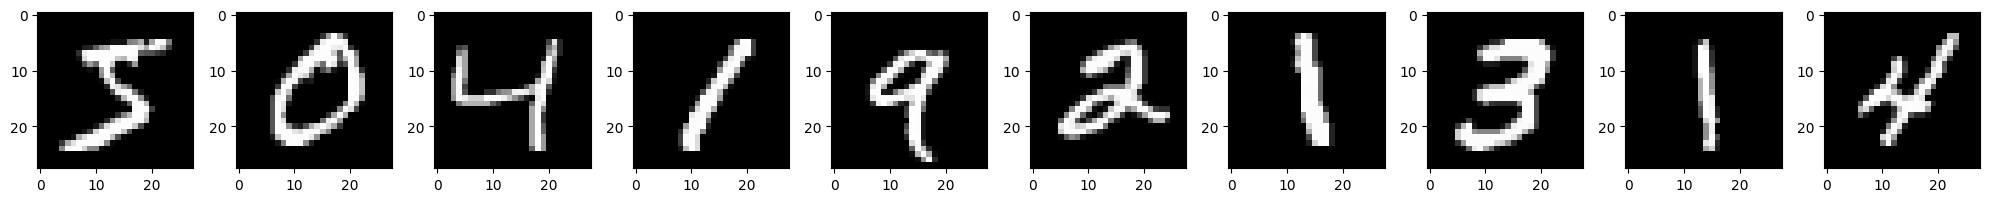

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=10, figsize=(20, 4))
for i in range(10):
  ax[i].imshow(X_train[i], cmap='gray')
plt.tight_layout()
plt.show()

#3-Configuration des couches du Réseau de Neurones


In [ ]:
model = keras.Sequential([
  keras.layers.Flatten(input_shape=(28, 28)), #couche d'entrée
  keras.layers.Dense(128, activation='relu'), #step function
  keras.layers.Dense(64, activation='relu'),
  keras.layers.Dense(10)]) #couche de sortie
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

#4-Entraînement du Réseau de Neurones

In [ ]:
# Compilation du modele

model.compile(optimizer='adam',
loss= keras.losses.SparseCategoricalCrossentropy(from_logits=True),
metrics=['accuracy'])

# Entrainement du modele
model.fit(X_train, y_train, epochs=10)
#y_train: labels
#loss: la difference entre la valeur prédit et la valeur réelle
#accuracy: TP/TP+TN

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8752 - loss: 0.4250
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9661 - loss: 0.1115
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9774 - loss: 0.0720
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9832 - loss: 0.0535
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9864 - loss: 0.0438
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9898 - loss: 0.0312
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9905 - loss: 0.0272
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9923 - loss: 0.0216
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9931 - loss: 0.0204
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9946 - loss: 0.0173


# 5-Évaluation du Réseau de Neurons sur les données de Test

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.1028
Test accuracy: 0.9760000109672546


# 6-Création d'un modele prédictif

In [ ]:
prediction_model = keras.Sequential([model, keras.layers.Softmax()])
predict_proba = prediction_model.predict(X_test)
predictions = np.argmax(predict_proba, axis=1)
print(predictions[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


# Exercice 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1-Dataset

dimensions de X: (100, 2)
dimensions de y: (100, 1)


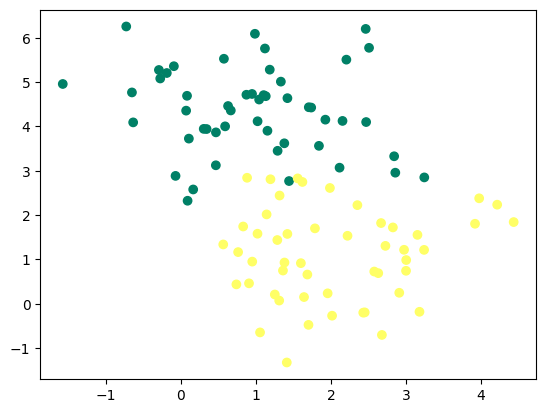

In [ ]:
X,y = make_blobs(n_samples=100, n_features=2, centers=2,random_state=0)
random_state=0,
y = y.reshape((y.shape[0], 1))
print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)
plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

# 2-Functions du modèle

0.87


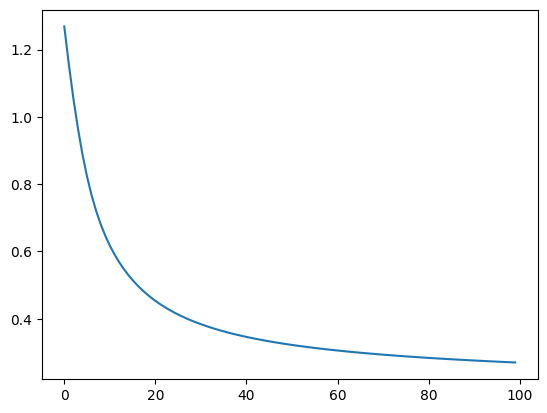

In [ ]:
def initialisation(X):
  W = np.random.randn(X.shape[1], 1)
  b = np.random.randn(1)
  return (W, b)
def model(X, W, b):
  Z = X.dot(W) + b
  A = 1 / (1 + np.exp(-Z))
  return A

def log_loss(A, y):
  return 1 / len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 -
  A))

def gradients(A, X, y):
  dW = 1 / len(y) * np.dot(X.T, A - y)
  db = 1 / len(y) * np.sum(A - y)
  return (dW, db)

def update(dW, db, W, b, learning_rate):
  W = W - learning_rate * dW
  b = b - learning_rate * db
  return (W, b)

def predict(X, W, b):
  A = model(X, W, b)
  # print(A)
  return A >= 0.5

from sklearn.metrics import accuracy_score

def artificial_neuron(X, y, learning_rate = 0.1, n_iter = 100):
# initialisation W, b
    W, b = initialisation(X)
    Loss = []
    for i in range(n_iter):
        A = model(X, W, b)
        Loss.append(log_loss(A, y))
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, learning_rate)
    y_pred = predict(X, W, b)
    print(accuracy_score(y, y_pred))
    plt.plot(Loss)
    plt.show()
    return (W, b)
W, b = artificial_neuron(X, y)


#3-Frontière de décision

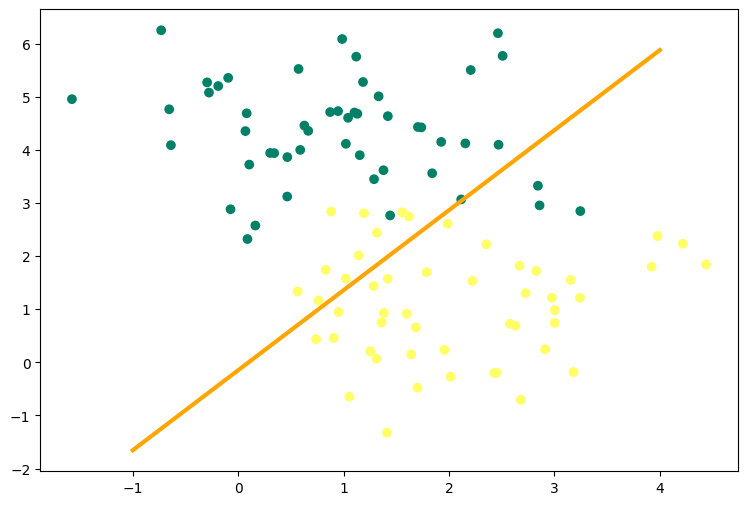

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
x1 = np.linspace(-1, 4, 100)
x2 = ( - W[0] * x1 - b) / W[1]
ax.plot(x1, x2, c='orange', lw=3)

# Exercice 3

# 1-Pretraitement des données

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd

df = pd.read_csv("AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
#Valeurs manquantes
VM = pd.DataFrame({
'Colonne': df.columns.values,
'nbr de VM': df.isna().sum().values,
'% de VM': 100 * df.isna().sum().values / len(df),})
VM = VM[VM['nbr de VM'] > 0]
print(VM.sort_values(by='nbr de VM',
ascending=False).reset_index(drop=True))

           Colonne  nbr de VM    % de VM
0          Pool QC       2917  99.556314
1     Misc Feature       2824  96.382253
2            Alley       2732  93.242321
3            Fence       2358  80.477816
4     Mas Vnr Type       1775  60.580205
5     Fireplace Qu       1422  48.532423
6     Lot Frontage        490  16.723549
7      Garage Qual        159   5.426621
8      Garage Cond        159   5.426621
9    Garage Yr Blt        159   5.426621
10   Garage Finish        159   5.426621
11     Garage Type        157   5.358362
12   Bsmt Exposure         83   2.832765
13  BsmtFin Type 2         81   2.764505
14       Bsmt Cond         80   2.730375
15       Bsmt Qual         80   2.730375
16  BsmtFin Type 1         80   2.730375
17    Mas Vnr Area         23   0.784983
18  Bsmt Full Bath          2   0.068259
19  Bsmt Half Bath          2   0.068259
20    BsmtFin SF 1          1   0.034130
21    BsmtFin SF 2          1   0.034130
22      Electrical          1   0.034130
23   Total Bsmt 

In [ ]:
#on affiche les variables catégorielles et les variables numériques
colonnes_avec_VM = df.columns[df.isna().sum() > 0]
for col in colonnes_avec_VM :
    print(col)
    print(df[col].unique()[:5])
    print('*'*30)

Lot Frontage
[141.  80.  81.  93.  74.]
******************************
Alley
[nan 'Pave' 'Grvl']
******************************
Mas Vnr Type
['Stone' nan 'BrkFace' 'BrkCmn' 'CBlock']
******************************
Mas Vnr Area
[112.   0. 108.  20. 603.]
******************************
Bsmt Qual
['TA' 'Gd' 'Ex' nan 'Fa']
******************************
Bsmt Cond
['Gd' 'TA' nan 'Po' 'Fa']
******************************
Bsmt Exposure
['Gd' 'No' 'Mn' 'Av' nan]
******************************
BsmtFin Type 1
['BLQ' 'Rec' 'ALQ' 'GLQ' 'Unf']
******************************
BsmtFin SF 1
[ 639.  468.  923. 1065.  791.]
******************************
BsmtFin Type 2
['Unf' 'LwQ' 'BLQ' 'Rec' nan]
******************************
BsmtFin SF 2
[   0.  144. 1120.  163.  168.]
******************************
Bsmt Unf SF
[ 441.  270.  406. 1045.  137.]
******************************
Total Bsmt SF
[1080.  882. 1329. 2110.  928.]
******************************
Electrical
['SBrkr' 'FuseA' 'FuseF' 'FuseP' nan]
***

In [ ]:
#on remplace les VM numériques par la moyenne de la colonne
num_VM = ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath',
'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars', 'Garage Area']
for n_col in num_VM:
    df[n_col] = df[n_col].fillna(df[n_col].mean())

In [ ]:
#On remplace les VM nominales par le mode variable
nom_VM = [x for x in colonnes_avec_VM if x not in num_VM]
for nom_col in nom_VM:
    df[nom_col] = df[nom_col].fillna(df[nom_col].mode().to_numpy()[0])

In [ ]:
#encodage des variables catégorielles
#on affiche tout d'abord les types de données pour chaque colonne
types = pd.DataFrame({
'Colonne': df.select_dtypes(exclude='object').columns.values,
'Type': df.select_dtypes(exclude='object').dtypes.values})
print(types)

            Colonne     Type
0             Order    int64
1               PID    int64
2       MS SubClass    int64
3      Lot Frontage  float64
4          Lot Area    int64
5      Overall Qual    int64
6      Overall Cond    int64
7        Year Built    int64
8    Year Remod/Add    int64
9      Mas Vnr Area  float64
10     BsmtFin SF 1  float64
11     BsmtFin SF 2  float64
12      Bsmt Unf SF  float64
13    Total Bsmt SF  float64
14       1st Flr SF    int64
15       2nd Flr SF    int64
16  Low Qual Fin SF    int64
17      Gr Liv Area    int64
18   Bsmt Full Bath  float64
19   Bsmt Half Bath  float64
20        Full Bath    int64
21        Half Bath    int64
22    Bedroom AbvGr    int64
23    Kitchen AbvGr    int64
24    TotRms AbvGrd    int64
25       Fireplaces    int64
26    Garage Yr Blt  float64
27      Garage Cars  float64
28      Garage Area  float64
29     Wood Deck SF    int64
30    Open Porch SF    int64
31   Enclosed Porch    int64
32       3Ssn Porch    int64
33     Screen 

In [ ]:
#encodage des variables catégorielles,
#selon le descriptif de la dataset la colonne MS SubClass est nominale,
#Pandas a du mal à retourner son vrai type
df['MS SubClass'] = df['MS SubClass'].astype(str)
selection_de_variables = ['MS SubClass', 'MS Zoning', 'Lot Frontage',
'Lot Area',
'Neighborhood', 'Overall Qual', 'Overall Cond',
'Year Built', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF',
'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
'Kitchen AbvGr', 'TotRms AbvGrd', 'Garage Area',
'Pool Area', 'SalePrice']
df = df[selection_de_variables]
#la dataset comprendera maintenant que 67 variables
df = pd.get_dummies(df)

In [ ]:
#fractionner dataset en des données de test et de train
train = df.sample(frac = 0.8, random_state = 9)
test = df.drop(train.index)
#variable cible
train_cible = train.pop('SalePrice')
test_cible = test.pop('SalePrice')

In [ ]:
#Standardisation
variables_pred = train.columns
for col in variables_pred:
    col_moyenne = train[col].mean()
    col_ecart_type = train[col].std()
    if col_ecart_type == 0:
       col_ecart_type = 1e-20
train[col] = (train[col] - col_moyenne) / col_ecart_type
test[col] = (test[col] - col_moyenne) / col_ecart_type

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

modele = keras.Sequential([
    keras.Input(shape=(train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3, seed=2),
    layers.Dense(64, activation='swish'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='swish'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='swish'),
    layers.Dense(1)
])

In [ ]:
import tensorflow as tf

#2-Compilation du modèle

In [ ]:
optimiseur = tf.keras.optimizers.RMSprop(learning_rate = 0.001)
modele.compile(loss = tf.keras.losses.MeanSquaredError(),optimizer =
optimiseur,metrics = ['mae'])

# 3-Entrainement du modèle

In [ ]:
training = modele.fit (train, train_cible, epochs = 70,
validation_split = 0.2)

Epoch 1/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 24509063168.0000 - mae: 127918.7578 - val_loss: 19305324544.0000 - val_mae: 59470.2656
Epoch 2/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6191405568.0000 - mae: 53500.7461 - val_loss: 9121709056.0000 - val_mae: 46917.4375
Epoch 3/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4710358528.0000 - mae: 46447.5078 - val_loss: 5337444352.0000 - val_mae: 39820.1797
Epoch 4/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4479387648.0000 - mae: 44988.8438 - val_loss: 4891392512.0000 - val_mae: 42376.8906
Epoch 5/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3998241536.0000 - mae: 43696.4805 - val_loss: 3953705728.0000 - val_mae: 36053.4102
Epoch 6/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3504738048.0000 - mae: 40534.8867 - val_loss: 3652204544.0000 - val_mae: 34920.4453
Epoch 7/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3365687552.0000 - mae: 39207.0820 - val_loss: 3471072000.0000 - val_mae: 34000.8086
Epo

# 4-Prévision

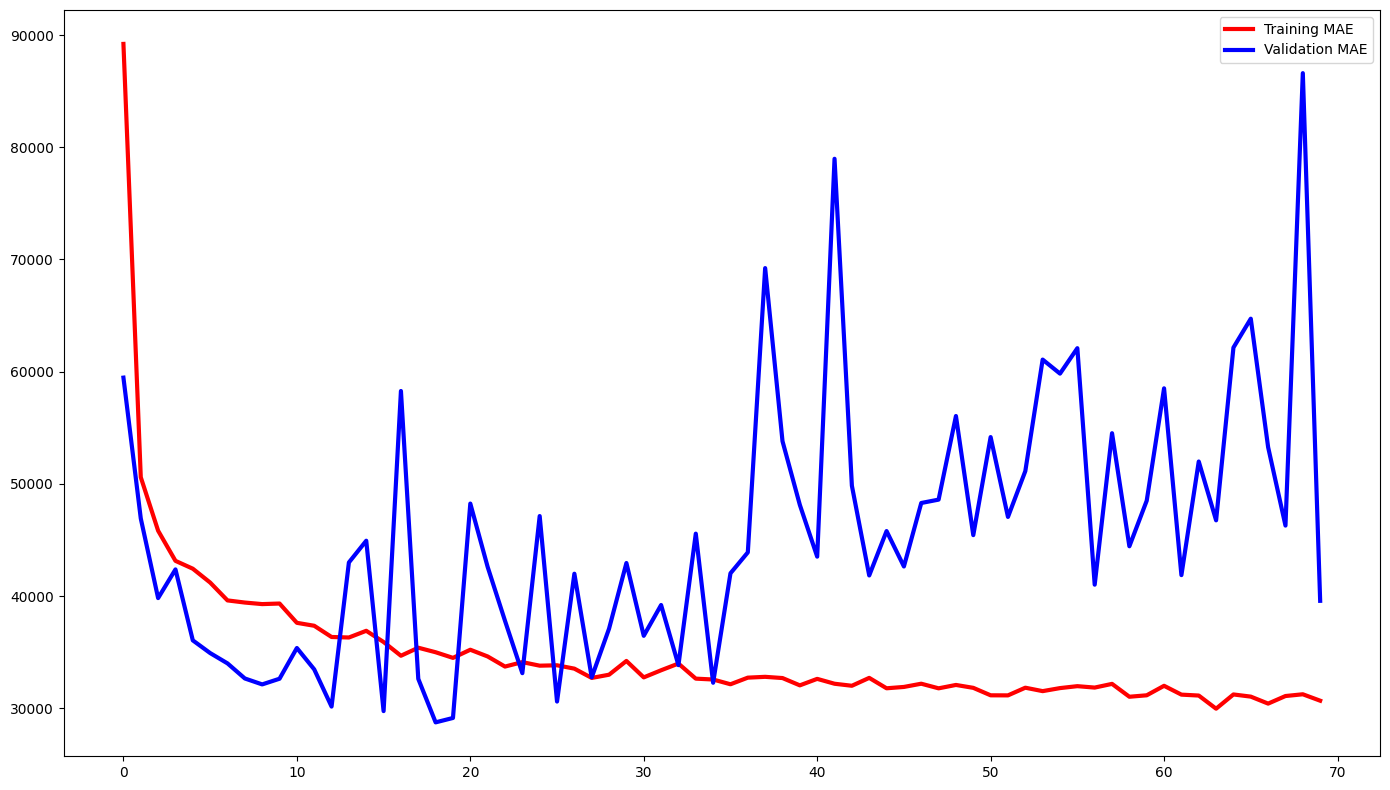

In [ ]:

historique = pd.DataFrame(training.history)
historique['epoque'] = training.epoch
figure, axe = plt.subplots(figsize = (14,8))
num_epoque = historique.shape[0]
axe.plot(np.arange(0, num_epoque), historique["mae"],label = "Training MAE", lw = 3, color = 'red')
axe.plot(np.arange(0, num_epoque), historique["val_mae"],label =
"Validation MAE", lw = 3, color = 'blue')
axe.legend ()
plt.tight_layout()
plt.show()

**4-1 Analyse de la courbe Training**

On observe que :

*   Au début de l'entraînement, l'erreur est très élevée (≈ 90000).
*   Ensuite l'erreur diminue rapidement.

*   Après plusieurs epochs, elle se stabilise autour de 31000 – 33000.

**Interprétation**

Cela signifie que :

*   le modèle apprend progressivement à partir des données
*   les poids du réseau neuronal s'ajustent pour réduire l'erreur

Donc l’apprentissage fonctionne correctement sur les données d’entraînement.


**4-2 Analyse de la courbe de Validation**

La courbe bleue montre un comportement différent :


*   Au début elle diminue aussi.
*   Elle atteint une valeur relativement faible autour de 32000 – 35000.
*   Ensuite elle devient très instable avec de fortes variations (jusqu'à 80000)

**Interprétation**

Cela signifie que :


*   le modèle n'est pas stable lorsqu'il fait des prédictions sur de nouvelles données.
*   Les fluctuations indiquent que les performances varient fortement selon les epochs.



**4-3 Interprétation globale**

La comparaison entre les deux courbes montre que :


*   l’erreur d’entraînement reste faible et stable
*   l’erreur de validation devient irrégulière

Cela suggère un phénomène de :

**Overfitting**

Le modèle apprend très bien les données d’entraînement mais généralise moins bien sur des données nouvelles.

Cependant l’overfitting n’est pas extrême, car les valeurs restent parfois proches.

